In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Atur tema visual grafik biar langsung keliatan elegan
sns.set_theme(style="darkgrid")

# Panggil file CSV-nya (Pastiin namanya udah bener ya!)
# Pakai low_memory=False karena datanya gede banget
df = pd.read_csv('male_players.csv', low_memory=False)

print("=== 🏟️ STATISTIK DATASET BOLA ===")
print(f"Jumlah Pemain: {df.shape[0]} orang")
print(f"Jumlah Atribut/Kolom: {df.shape[1]} statistik\n")

# Mari kita intip 5 pemain dengan rating tertinggi di dunia!
kolom_penting = ['short_name', 'age', 'nationality_name', 'club_name', 'overall', 'potential', 'value_eur']
display(df[kolom_penting].head())

=== 🏟️ STATISTIK DATASET BOLA ===
Jumlah Pemain: 180021 orang
Jumlah Atribut/Kolom: 109 statistik



,short_name,age,nationality_name,club_name,overall,potential,value_eur
0,K. Mbappé,24,France,Paris Saint Germain,91,94,181500000.0
1,E. Haaland,22,Norway,Manchester City,91,94,185000000.0
2,K. De Bruyne,32,Belgium,Manchester City,91,91,103000000.0
3,L. Messi,36,Argentina,Inter Miami,90,90,41000000.0
4,K. Benzema,35,France,Al Ittihad,90,90,51000000.0


C:\Users\aqill\AppData\Local\Temp\ipykernel_8576\1092898482.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_negara.values, y=top_negara.index, ax=axes[1], palette='viridis')


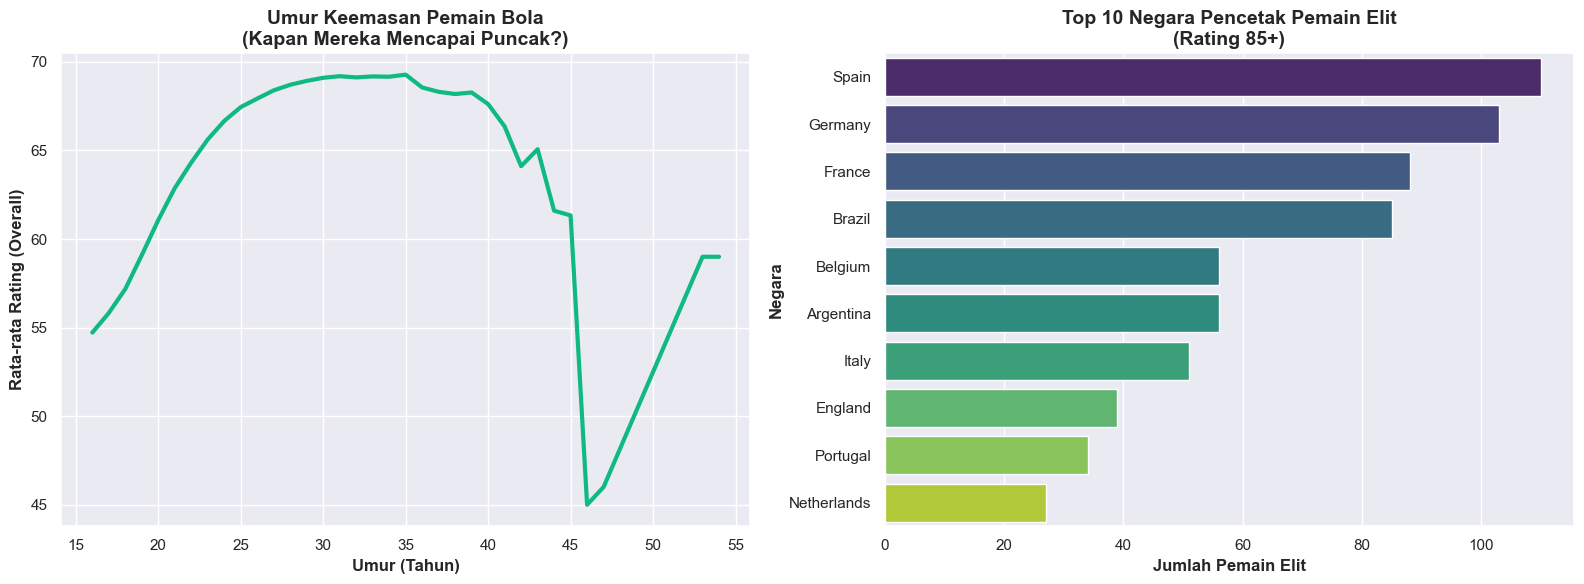

In [6]:
# Bikin kanvas gede buat 2 grafik sebelahan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFIK 1: Umur Keemasan Pemain Bola (Line Plot) ---
# Kita kelompokkan berdasarkan umur, lalu cari rata-rata ratingnya
umur_rating = df.groupby('age')['overall'].mean().reset_index()

sns.lineplot(data=umur_rating, x='age', y='overall', ax=axes[0], color='#10B981', linewidth=3)
axes[0].set_title('Umur Keemasan Pemain Bola\n(Kapan Mereka Mencapai Puncak?)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Umur (Tahun)', fontweight='bold')
axes[0].set_ylabel('Rata-rata Rating (Overall)', fontweight='bold')

# --- GRAFIK 2: Negara Penghasil Pemain Dewa (Bar Plot) ---
# Kita saring cuma pemain elit yang ratingnya 85 ke atas
pemain_dewa = df[df['overall'] >= 85]
top_negara = pemain_dewa['nationality_name'].value_counts().head(10)

sns.barplot(x=top_negara.values, y=top_negara.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Negara Pencetak Pemain Elit\n(Rating 85+)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Jumlah Pemain Elit', fontweight='bold')
axes[1].set_ylabel('Negara', fontweight='bold')

plt.tight_layout()
plt.show()

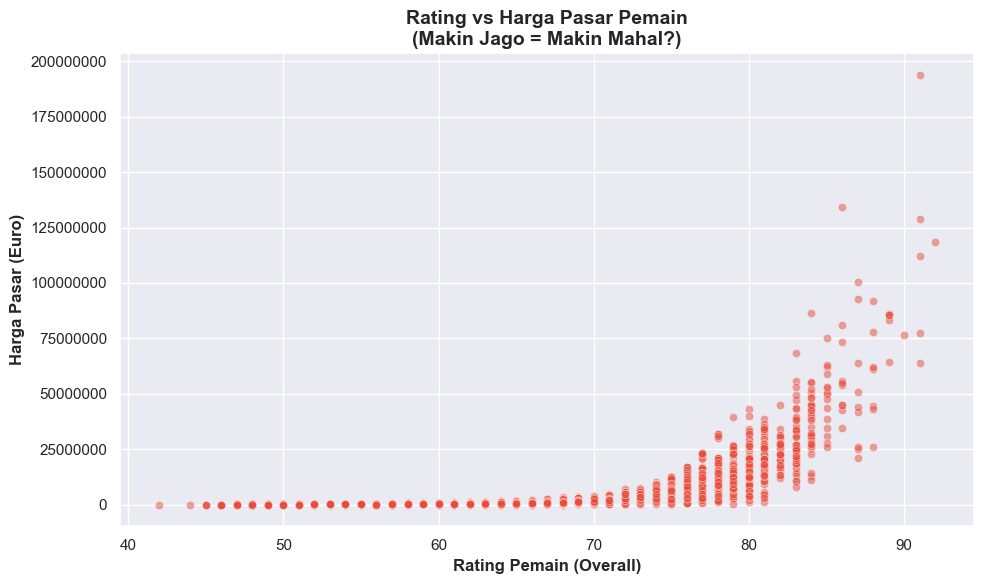

In [7]:
plt.figure(figsize=(10, 6))

# Kita ambil sampel 10.000 pemain aja biar grafiknya gak terlalu berat pas di-render
df_sample = df.sample(10000, random_state=42)

# Bikin Scatter Plot: X = Rating, Y = Harga (Value)
sns.scatterplot(data=df_sample, x='overall', y='value_eur', alpha=0.5, color='#E74C3C')

plt.title('Rating vs Harga Pasar Pemain\n(Makin Jago = Makin Mahal?)', fontweight='bold', fontsize=14)
plt.xlabel('Rating Pemain (Overall)', fontweight='bold')
plt.ylabel('Harga Pasar (Euro)', fontweight='bold')

# Biar format angkanya gampang dibaca (gak pake format saintifik kayak 1e8)
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()